In [ ]:
from google.colab import files
uploaded=files.upload()

Saving telco.csv.csv to telco.csv.csv


In [ ]:
import os
print(os.listdir())

['.config', 'telco.csv.csv', 'sample_data']


In [ ]:
import pandas as pd
df=pd.read_csv("telco.csv.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],
errors='coerce')

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),
inplace=True)

/tmp/ipykernel_7128/669022824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),


In [ ]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [ ]:
df.drop('customerID',axis=1,inplace=True)

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
print("after cleaning",df.shape)

after cleaning (7043, 31)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
churn_rate=df['Churn'].mean()
print("Churn Rate:",churn_rate)

Churn Rate: 0.2653698707936959


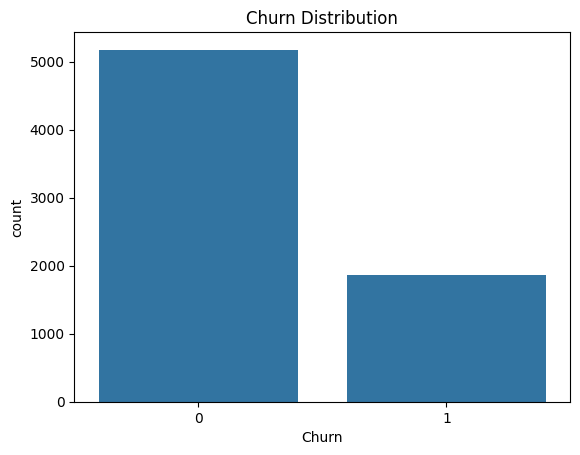

In [ ]:
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

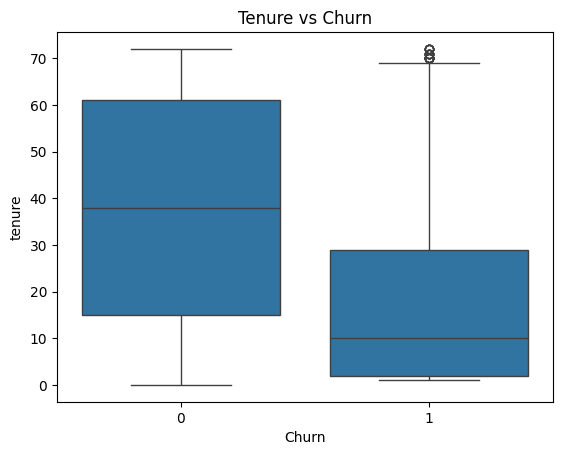

In [ ]:
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title("Tenure vs Churn")
plt.show()


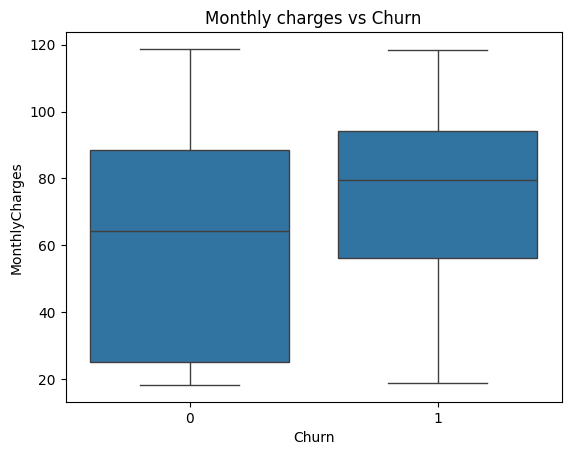

In [ ]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly charges vs Churn")
plt.show()

In [ ]:
df['TenureGroup']=pd.cut(df['tenure'],
                bins=[0,12,24,60,100],
                labels=['0-1yr','1-2yr','2-5yr','5+yr'])

In [ ]:
segmentation=df.groupby('TenureGroup')['Churn'].mean()
print(segmentation)

TenureGroup
0-1yr    0.476782
1-2yr    0.287109
2-5yr    0.183430
5+yr     0.066098
Name: Churn, dtype: float64


/tmp/ipykernel_7128/3375085022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentation=df.groupby('TenureGroup')['Churn'].mean()


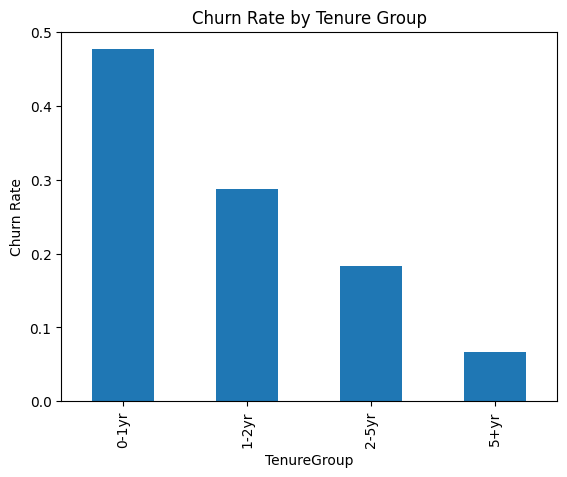

In [ ]:
segmentation.plot(kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
test_size=0.2,random_state=42)

In [ ]:
print(df.dtypes)
if 'TenureGroup' in df.columns:
    df.drop('TenureGroup',axis=1,inplace=True)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],
errors='coerce' )

In [ ]:
df=df.fillna(df.median())

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8218594748048261


In [ ]:
print(confusion_matrix(y_test,y_pred))

[[934 102]
 [149 224]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [13]:
import shutil
shutil.make_archive("Churn_project",'zip','/content')

'/content/Churn_project.zip'

In [14]:
from google.colab import files
files.download("Churn_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>